<a href="https://colab.research.google.com/github/BilalKhaliqWillis/BILAL-Assignment2/blob/main/BILAL_Assignment_12_Time_Series_Preparation_and_GRU_Forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Uploading the Dataset
from google.colab import files
uploaded = files.upload()

Saving iot_reading.csv to iot_reading.csv


In [2]:
# Importing all Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

In [3]:
# Loading Dataset
ts_power = pd.read_csv("iot_reading.csv")

# Converting timestamp column
ts_power["timestamp"] = pd.to_datetime(ts_power["Unnamed: 0"])

# Dropping old column
ts_power = ts_power.drop(columns=["Unnamed: 0"])

# Setting index
ts_power = ts_power.set_index("timestamp")

print(ts_power.head())

                          load
timestamp                     
2021-01-01 00:00:00  20.149014
2021-01-01 01:00:00  20.994297
2021-01-01 02:00:00  22.196307
2021-01-01 03:00:00  23.289836
2021-01-01 04:00:00  23.401856


In [4]:
# Part A — Data Exploration
print(ts_power.head())

                          load
timestamp                     
2021-01-01 00:00:00  20.149014
2021-01-01 01:00:00  20.994297
2021-01-01 02:00:00  22.196307
2021-01-01 03:00:00  23.289836
2021-01-01 04:00:00  23.401856


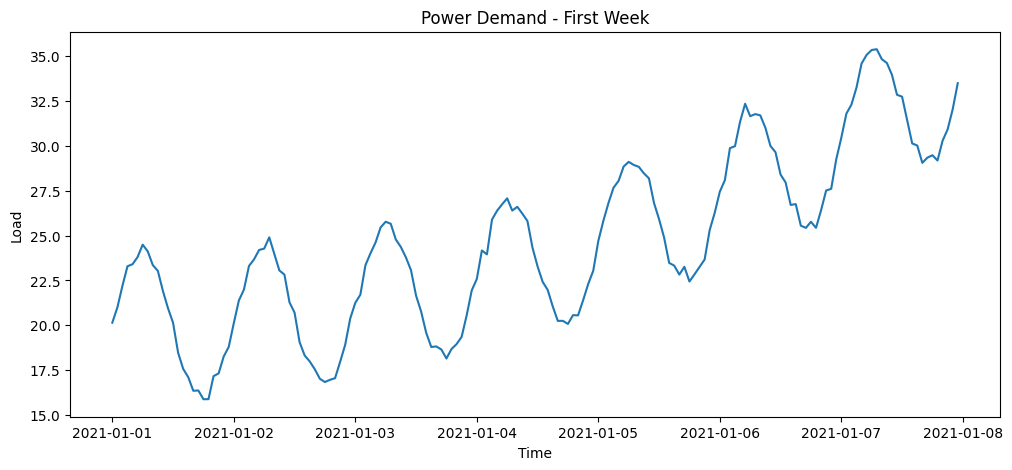

In [6]:
# Plotting First Week of Data
# First week = 24 × 7 = 168 hours
first_week = ts_power.iloc[:168]

plt.figure(figsize=(12,5))
plt.plot(first_week.index, first_week["load"])
plt.title("Power Demand - First Week")
plt.xlabel("Time")
plt.ylabel("Load")
plt.show()

# This plot is showing variability and daily patterns in power demand

In [9]:
# Part B — Train / Validation / Test Split
# Chronological Split

n = len(ts_power)

train_end = int(n * 0.60)
valid_end = int(n * 0.80)

train_data = ts_power.iloc[:train_end]
valid_data = ts_power.iloc[train_end:valid_end]
test_data  = ts_power.iloc[valid_end:]

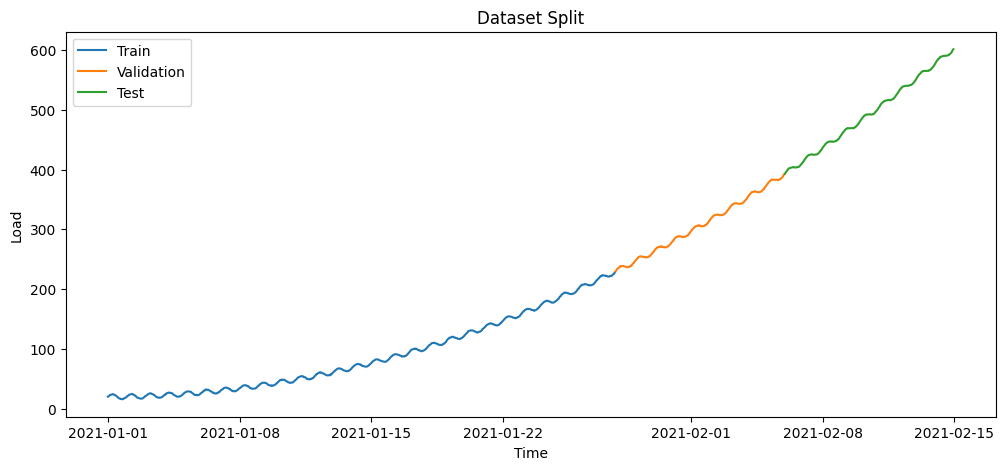

In [10]:
# Plotting Splits
plt.figure(figsize=(12,5))

plt.plot(train_data.index, train_data["load"], label="Train")
plt.plot(valid_data.index, valid_data["load"], label="Validation")
plt.plot(test_data.index, test_data["load"], label="Test")

plt.title("Dataset Split")
plt.xlabel("Time")
plt.ylabel("Load")
plt.legend()
plt.show()

In [11]:
# Printing Date Ranges
print("Train Range:", train_data.index.min(), "to", train_data.index.max())
print("Validation Range:", valid_data.index.min(), "to", valid_data.index.max())
print("Test Range:", test_data.index.min(), "to", test_data.index.max())

Train Range: 2021-01-01 00:00:00 to 2021-01-27 23:00:00
Validation Range: 2021-01-28 00:00:00 to 2021-02-05 23:00:00
Test Range: 2021-02-06 00:00:00 to 2021-02-14 23:00:00


In [12]:
# Data Scaling
# Fitting MinMaxScaler on Train Only
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data)
valid_scaled = scaler.transform(valid_data)
test_scaled  = scaler.transform(test_data)

In [13]:
# Converting Back to DataFrames
train_scaled = pd.DataFrame(train_scaled, columns=["load"], index=train_data.index)
valid_scaled = pd.DataFrame(valid_scaled, columns=["load"], index=valid_data.index)
test_scaled  = pd.DataFrame(test_scaled, columns=["load"], index=test_data.index)

In [14]:
# Showing Head of Scaled Data
print(train_scaled.head())

                         load
timestamp                    
2021-01-01 00:00:00  0.020057
2021-01-01 01:00:00  0.024038
2021-01-01 02:00:00  0.029698
2021-01-01 03:00:00  0.034847
2021-01-01 04:00:00  0.035375


Why Scaling is Important?

Neural networks are training using gradient-based optimization. If the feature values have very different scales, then training becomes quite unstable and slow. MinMaxScaler rescales values between 0 and 1, which in turn helps neural networks join faster and increases numerical stability.

In [15]:
# Part D — Shifting and Lag Features
# Defining Parameters
T = 8
HORIZON = 2

In [16]:
# Creating Target Column
train_shifted = train_scaled.copy()

# Future target
train_shifted["y_t+2"] = train_shifted["load"].shift(-HORIZON)

In [17]:
# Creating Lag Features
for i in range(1, T+1):
    train_shifted[f"load_t-{i}"] = train_shifted["load"].shift(i)

train_shifted.head(12)

,load,y_t+2,load_t-1,load_t-2,load_t-3,load_t-4,load_t-5,load_t-6,load_t-7,load_t-8
timestamp,,,,,,,,,,
2021-01-01 00:00:00,0.020057,0.029698,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-01 01:00:00,0.024038,0.034847,0.020057,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-01 02:00:00,0.029698,0.035375,0.024038,0.020057,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-01 03:00:00,0.034847,0.037277,0.029698,0.024038,0.020057,NaN,NaN,NaN,NaN,NaN
2021-01-01 04:00:00,0.035375,0.040507,0.034847,0.029698,0.024038,0.020057,NaN,NaN,NaN,NaN
2021-01-01 05:00:00,0.037277,0.038749,0.035375,0.034847,0.029698,0.024038,0.020057,NaN,NaN,NaN
2021-01-01 06:00:00,0.040507,0.035155,0.037277,0.035375,0.034847,0.029698,0.024038,0.020057,NaN,NaN
2021-01-01 07:00:00,0.038749,0.033632,0.040507,0.037277,0.035375,0.034847,0.029698,0.024038,0.020057,NaN
2021-01-01 08:00:00,0.035155,0.028354,0.038749,0.040507,0.037277,0.035375,0.034847,0.029698,0.024038,0.020057


In [18]:
# Shaping Before Dropping Missing Rows
print("Shape before dropping NaN:", train_shifted.shape)

Shape before dropping NaN: (648, 10)


In [19]:
# Dropping Missing Rows
train_shifted = train_shifted.dropna()

print("Shape after dropping NaN:", train_shifted.shape)

Shape after dropping NaN: (638, 10)


In [20]:
# Part E — Reshape into 3D Tensor
# Separating Features and Target
X_train = train_shifted[[f"load_t-{i}" for i in range(1, T+1)]].values
y_train = train_shifted["y_t+2"].values

In [21]:
#Reshape for LSTM/GRU
# Required shapes:- (samples, timesteps, features)

X_train = X_train.reshape((X_train.shape[0], T, 1))

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (638, 8, 1)
y_train shape: (638,)


In [22]:
# Verifying Lag Structure
train_shifted.head()

,load,y_t+2,load_t-1,load_t-2,load_t-3,load_t-4,load_t-5,load_t-6,load_t-7,load_t-8
timestamp,,,,,,,,,,
2021-01-01 08:00:00,0.035155,0.028354,0.038749,0.040507,0.037277,0.035375,0.034847,0.029698,0.024038,0.020057
2021-01-01 09:00:00,0.033632,0.023858,0.035155,0.038749,0.040507,0.037277,0.035375,0.034847,0.029698,0.024038
2021-01-01 10:00:00,0.028354,0.020036,0.033632,0.035155,0.038749,0.040507,0.037277,0.035375,0.034847,0.029698
2021-01-01 11:00:00,0.023858,0.012176,0.028354,0.033632,0.035155,0.038749,0.040507,0.037277,0.035375,0.034847
2021-01-01 12:00:00,0.020036,0.007962,0.023858,0.028354,0.033632,0.035155,0.038749,0.040507,0.037277,0.035375


In [23]:
# I will have to apply same steps to Validation and Test
# Function to Create Lag Features
def create_lagged_features(df, T=8, HORIZON=2):

    df_shifted = df.copy()

    df_shifted["y_t+2"] = df_shifted["load"].shift(-HORIZON)

    for i in range(1, T+1):
        df_shifted[f"load_t-{i}"] = df_shifted["load"].shift(i)

    df_shifted = df_shifted.dropna()

    X = df_shifted[[f"load_t-{i}" for i in range(1, T+1)]].values
    y = df_shifted["y_t+2"].values

    X = X.reshape((X.shape[0], T, 1))

    return X, y, df_shifted

In [24]:
# Creating Validation Data
X_valid, y_valid, valid_shifted = create_lagged_features(valid_scaled, T, HORIZON)

print("X_valid shape:", X_valid.shape)
print("y_valid shape:", y_valid.shape)

X_valid shape: (206, 8, 1)
y_valid shape: (206,)


In [25]:
# Creating Test Data
X_test, y_test, test_shifted = create_lagged_features(test_scaled, T, HORIZON)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (206, 8, 1)
y_test shape: (206,)


In [26]:
# Part G — GRU Model for Forecasting
# Importing Deep Learning Libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [27]:
# Building GRU Model
# Define GRU Model
model = Sequential()

model.add(GRU(32, input_shape=(8,1)))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

"""Explanaining it: -

GRU(32) -> 32 memory units

input_shape = (8,1) -> 8 lag hours, 1 feature

Dense(1) -> predicts the future load value"""

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

'Explanaining it: -\n\nGRU(32) -> 32 memory units\n\ninput_shape = (8,1) -> 8 lag hours, 1 feature\n\nDense(1) -> predicts the future load value'

In [28]:
# Early Stopping
# Stops training if validation stops improving
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [29]:
# Training GRU Model
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0535 - mae: 0.1667 - val_loss: 0.0303 - val_mae: 0.1610
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0099 - mae: 0.0856 - val_loss: 0.0427 - val_mae: 0.1999
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0018 - mae: 0.0347 - val_loss: 7.0093e-04 - val_mae: 0.0224
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.6909e-04 - mae: 0.0205 - val_loss: 6.1274e-04 - val_mae: 0.0209
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.2833e-04 - mae: 0.0202 - val_loss: 0.0011 - val_mae: 0.0268
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.9930e-04 - mae: 0.0198 - val_loss: 7.4050e-04 - val_mae: 0.0228
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.2639e-04 - mae: 0.0206 - val_loss: 0.0011 - val_mae: 0.0272
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.0504e-04 - mae: 0.0202 - val_loss: 0.0012 - val_mae: 0.0286
Epoch 9/30
20/20 ━━━━━━━━━━━━━━━━━━

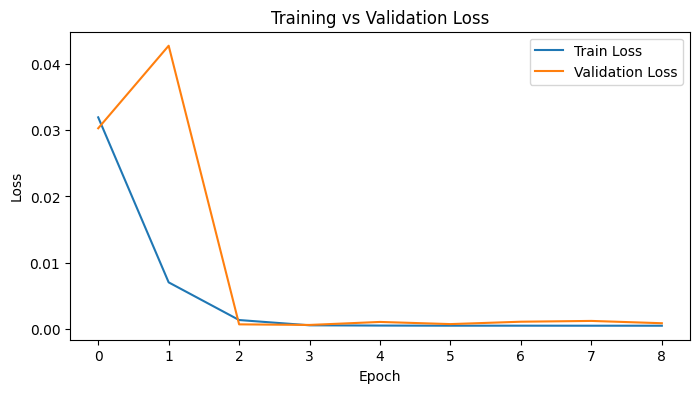

In [31]:
# Plotting Training History
plt.figure(figsize=(8,4))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# This plot shows how the model has learned and if the overfitting happens

In [32]:
# Test Set Prediction
y_pred = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step


In [33]:
# Converting Predictions Back to the Original Scale
# Now because we used MinMaxScaler, predictions will be scaled
y_pred_rescaled = scaler.inverse_transform(y_pred.reshape(-1,1))
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1,1))

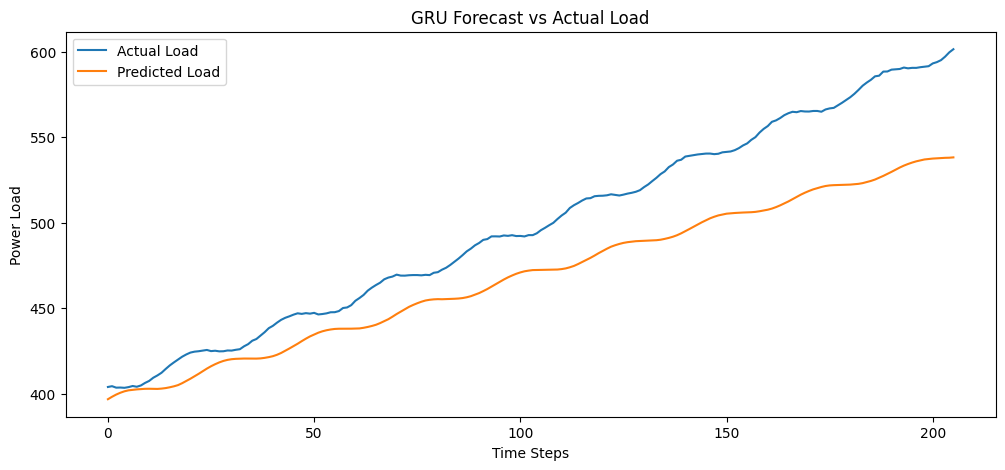

In [35]:
# Plotting - Actual vs Predicted Load
plt.figure(figsize=(12,5))

plt.plot(y_test_rescaled, label="Actual Load")
plt.plot(y_pred_rescaled, label="Predicted Load")

plt.title("GRU Forecast vs Actual Load")
plt.xlabel("Time Steps")
plt.ylabel("Power Load")

plt.legend()
plt.show()